In [1]:
# installing kaggle library
! pip install kaggle

Upload your kaggle.json file in drive/MyDrive

In [2]:
# configuring the path of kaggle.json file
!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


Importing Twitter Sentiment dataset

In [3]:
# API to fetch the dataset from kaggle
!kaggle datasets download -d kazanova/sentiment140

Dataset URL: https://www.kaggle.com/datasets/kazanova/sentiment140
License(s): other
  0% 0.00/80.9M [00:00<?, ?B/s]
100% 80.9M/80.9M [00:00<00:00, 1.52GB/s]


In [4]:
# extracting the compressed dataset
from zipfile import ZipFile
dataset='/content/sentiment140.zip'

with ZipFile(dataset, 'r') as zip:

  zip.extractall()

  print('The dataset is extracted')

The dataset is extracted


Importing the Dependencies

In [5]:
import numpy as np

import pandas as pd

import re

from nltk.corpus import stopwords

from nltk.stem.porter import PorterStemmer

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score

In [6]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [7]:
# printing the stopwords in English
print(stopwords.words('english'))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [8]:
# loading the data from csv file to pandas dataframe
twitter_data = pd.read_csv('/content/training.1600000.processed.noemoticon.csv', encoding='ISO-8859-1')

Data processing

In [9]:
twitter_data.shape

(1599999, 6)

"Why 1,599,999? Because indexing starts from 0, so we adjust it in the next steps."

In [10]:
# printing the first 5 rows of the dataframe
twitter_data.head()

,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew


In [11]:
# Naming the columns and reading the dataset again, because we can observe in the above step that the columns are not named
column_names = ['target' , 'id' ,'date', 'flag','user','text']
twitter_data = pd.read_csv('/content/training.1600000.processed.noemoticon.csv', names = column_names, encoding='ISO-8859-1')

In [12]:
 # checking the number of rows and columns
 twitter_data.shape

(1600000, 6)

In [13]:
twitter_data.head()

,target,id,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


target = 0 → negative sentiment
id = 1467810369 → tweet ID
date = Mon Apr 06 22:19:45 PDT 2009 → when it was posted
flag = NO_QUERY → not part of a query
user = TheSpecialOne → Twitter handle
text = tweet content

Why flag?
It indicates which query or keyword was used to collect that tweet.
For example:
flag value	meaning
NO_QUERY	The tweet wasn’t collected using any specific search keyword.
happy -	The tweet was collected using the keyword “happy”.
sad -	The tweet was collected using the keyword “sad”.


In [14]:
# counting the number of missing values in the dataset
twitter_data.isnull().sum()

,0
target,0
id,0
date,0
flag,0
user,0
text,0


1) Find number of twitters

In [15]:
# checking the distribution of target column
twitter_data['target'].value_counts()

,count
target,
0,800000
4,800000


Convert the target 4 to 1

In [16]:
twitter_data.replace({'target':{4:1}}, inplace=True) # why inplace = true beacause to replace or use it in original or recent.

In [17]:
print(twitter_data['target'].value_counts())

target
0    800000
1    800000
Name: count, dtype: int64


Keep 3 labels: 0 (Negative), 2 (Neutral), 4 (Positive)



Stemming is the process of reducing a word to its Root word

example: actor,actress,acting = act

In [18]:
port_stem = PorterStemmer()

Important part of this code

In [19]:
def stemming(content):

 stemmed_content = re.sub('[^a-zA-Z]',' ', content) # removing that are not letters like @,1,etc.
 stemmed_content = stemmed_content.lower() # because capital don't add any meaning to context.
 stemmed_content = stemmed_content.split() # after split adding into list
 stemmed_content=[port_stem.stem(word) for word in stemmed_content if not word in stopwords.words('english')] # Checking if there are any stopwords and if present, then it will be ignore in this step.
 stemmed_content = ' '.join(stemmed_content)

 return stemmed_content

In [ ]:
twitter_data['stemmed_content'] = twitter_data['text'].apply(stemming) # 50 minutes to run

In [ ]:
twitter_data.head()

In [ ]:
print(twitter_data['stemmed_content']) # It prints id & text(tweet)

In [ ]:
print(twitter_data['target']) # id & Target

In [ ]:
X = twitter_data['stemmed_content'].values
Y = twitter_data['target'].values

In [ ]:
print(X)

In [ ]:
print(Y)

Splitting the data to training data and test data

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, stratify = Y, random_state = 2)
# test_size = 0.2 indicates that 20% of the dataset will be used for testing, while the remaining 80% will be used for training the model.
# stratify = Y because Ensures that the proportion of each class in Y is preserved in both train and test sets.
# Without stratify, the split might randomly assign more samples of one class to either train or test, causing imbalance.

In [ ]:
print(X.shape, Y_train.shape, X_test.shape)

In [ ]:
print(X_test)

Feature extration

In [ ]:
#converting the textual data to numerical data

vectorizer = TfidfVectorizer() # Vectorizer(function) transforms text into numerical features by counting word occurrences. Frequent and meaningful words, like 'happy', help the model distinguish between positive and negative tweets.

X_train = vectorizer.fit_transform(X_train)

X_test = vectorizer.transform(X_test)

In [ ]:
print(X_train)

In [ ]:
print(X_test)

Training the Machine Learning Model

Logistic Regression

In [ ]:
model = LogisticRegression(max_iter=1000) # maximum no.of model can go through the data

In [ ]:
model.fit(X_train, Y_train) # model.fit(X_train, Y_train) trains the model by learning patterns between input features and their corresponding output labels.

Model Evaluation

Accuracy score

In [ ]:
# accuracy score on the training data
X_train_prediction = model.predict(X_train)
training_data_accuracy = accuracy_score(Y_train, X_train_prediction)

In [ ]:
print('Accuracy score on the training data:', training_data_accuracy)

In [ ]:
# accuracy score on the test data
X_test_prediction = model.predict(X_test)
test_data_accuracy = accuracy_score(Y_test, X_test_prediction)

In [ ]:
print('Accuracy score on the test data:', test_data_accuracy)

Model accuary = 77.8 %

Saving the trained model

In [ ]:
import pickle

In [ ]:
filename = 'trained_model.sav'
pickle.dump(model, open(filename,'wb'))

In [ ]:
# loading the saved model
loaded_model = pickle.load(open('/content/trained_model.sav','rb'))

In [ ]:
pickle.dump(vectorizer, open('vectorizer.sav', 'wb'))

In [ ]:
vectorizer = pickle.load(open('vectorizer.sav', 'rb'))

In [ ]:
# Try any random test sample
sample_index = 205
print("Actual Sentiment:", Y_test[sample_index])

prediction = loaded_model.predict(X_test[sample_index])
print("Predicted Sentiment:", prediction)

if prediction[0] == 0:
    print("Negative Tweet")
elif prediction[0] == 2:
    print("Neutral Tweet")
else:
    print("Positive Tweet")


In [48]:
import re
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
import pickle

# Load only the model (you already have vectorizer in memory)
loaded_model = pickle.load(open('trained_model.sav', 'rb'))

# Define stemming function (same as training)
port_stem = PorterStemmer()
def stemming(content):
    stemmed_content = re.sub('[^a-zA-Z]', ' ', content)
    stemmed_content = stemmed_content.lower()
    stemmed_content = stemmed_content.split()
    stemmed_content = [port_stem.stem(word) for word in stemmed_content if not word in stopwords.words('english')]
    return ' '.join(stemmed_content)

# ----- ✨ INPUT YOUR TEXT HERE -----
user_input = input("Enter a tweet or sentence: ")

# Preprocess
processed_input = stemming(user_input)

# Convert text to numeric (using the vectorizer you trained earlier)
vector_input = vectorizer.transform([processed_input])

# Predict sentiment
prediction = loaded_model.predict(vector_input)

# Print result
if prediction[0] == 0:
    print("🟥 Sentiment: Negative")
elif prediction[0] == 2:
    print("🟨 Sentiment: Neutral")
else:
    print("🟩 Sentiment: Positive")


Enter a tweet or sentence: the product is bad
🟥 Sentiment: Negative


In [49]:
import plotly.express as px
import pandas as pd

# Example sentiment data
sentiment_data = pd.DataFrame({
    'Sentiment': ['Positive', 'Neutral', 'Negative'],
    'Count': [1200, 500, 800]
})

fig = px.pie(sentiment_data, names='Sentiment', values='Count',
             title='Sentiment Distribution')
fig.show()


In [55]:
df = pd.read_csv('/content/training.1600000.processed.noemoticon.csv', encoding='ISO-8859-1')


In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='sentiment', palette='viridis')

plt.title('Sentiment Distribution', fontsize=14)
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()


ValueError: Could not interpret value `sentiment` for `x`. An entry with this name does not appear in `data`.

<Figure size 600x400 with 0 Axes>

/tmp/ipython-input-4210051466.py:15: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




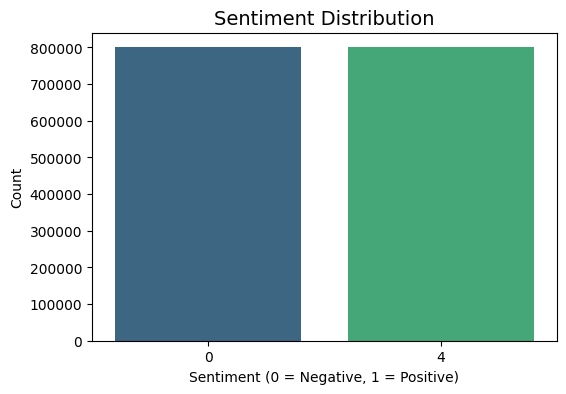

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Naming the columns and reading the dataset
column_names = ['target', 'id', 'date', 'flag', 'user', 'text']
twitter_data = pd.read_csv(
    '/content/training.1600000.processed.noemoticon.csv',
    names=column_names,
    encoding='ISO-8859-1'
)

# Plotting the sentiment distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=twitter_data, x='target', palette='viridis')
plt.title('Sentiment Distribution', fontsize=14)
plt.xlabel('Sentiment (0 = Negative, 1 = Positive)')
plt.ylabel('Count')
plt.show()


In [63]:
print(df.columns.tolist())

['0', '1467810369', 'Mon Apr 06 22:19:45 PDT 2009', 'NO_QUERY', '_TheSpecialOne_', "@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D"]


In [66]:
df.columns = df.columns.str.strip()


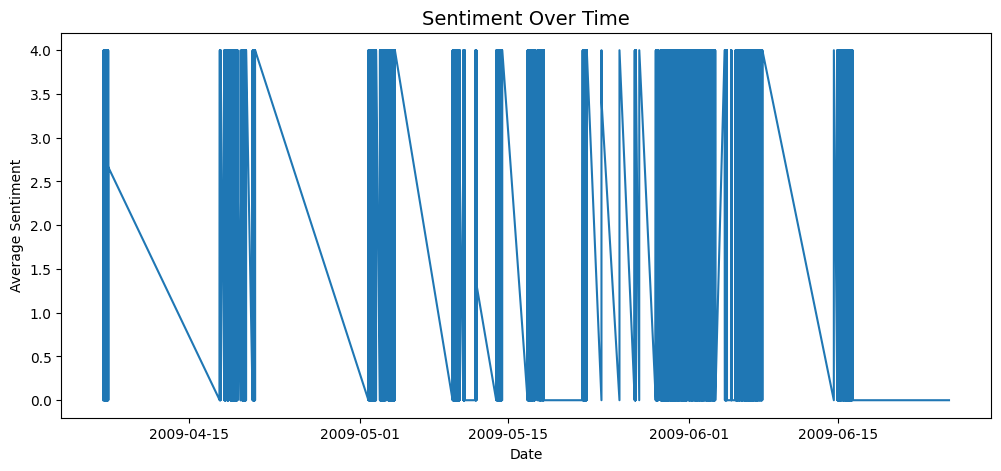

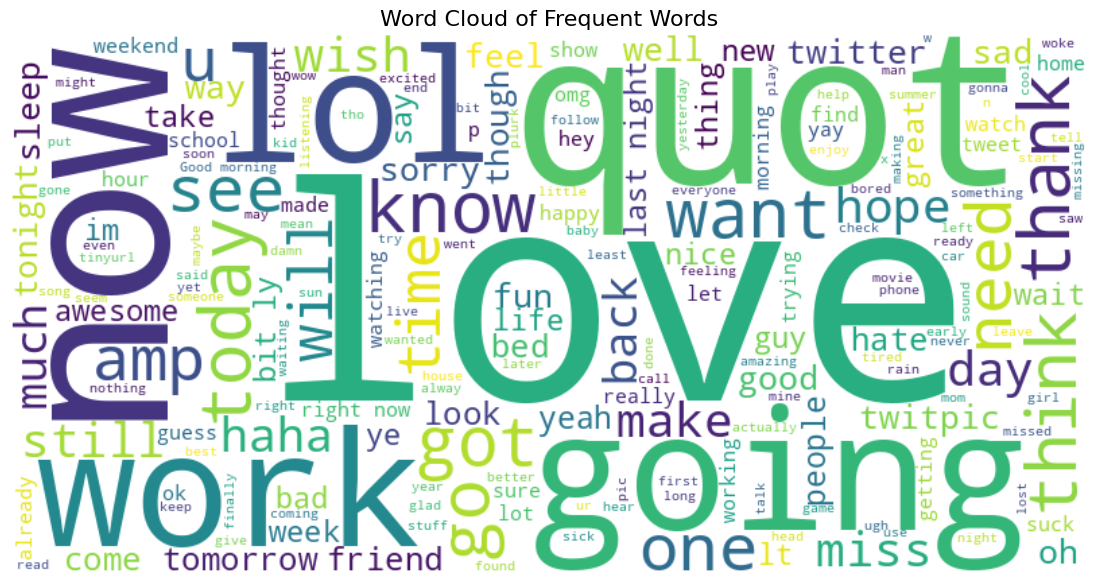

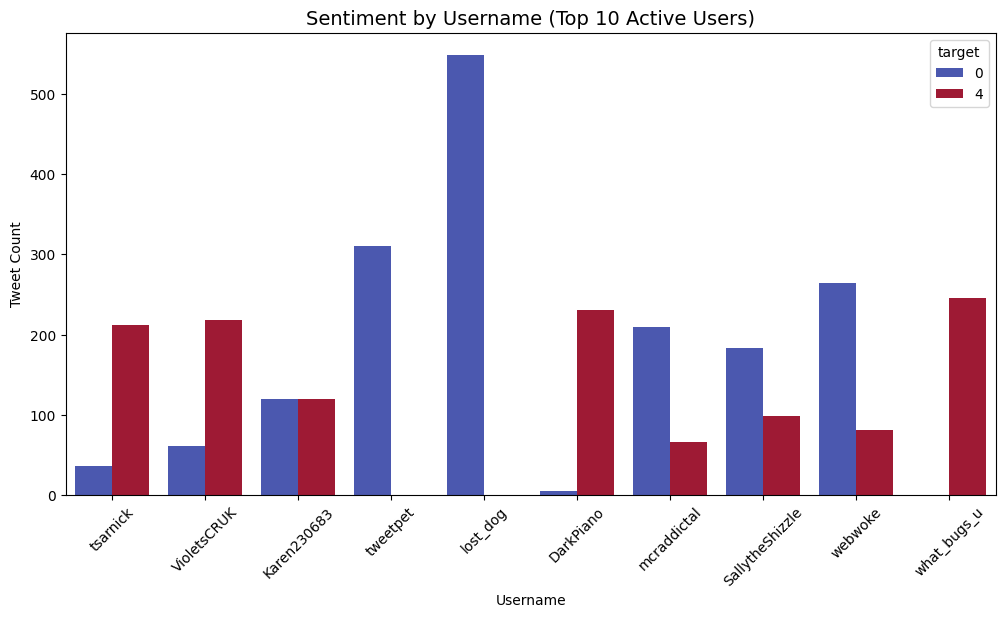

In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

# Use the preprocessed 'text' column
all_words = ' '.join(twitter_data['text'])

# 1. Sentiment Over Time (Line Chart)
twitter_data['date'] = pd.to_datetime(twitter_data['date'])
sentiment_over_time = twitter_data.groupby('date')['target'].mean().reset_index()

plt.figure(figsize=(12,5))
sns.lineplot(data=sentiment_over_time, x='date', y='target')
plt.title('Sentiment Over Time', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Average Sentiment')
plt.show()

# 2. Word Cloud of Frequent Words
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Frequent Words', fontsize=16)
plt.show()


# 3. Sentiment by Username (Top 10 Active Users)
top_users = twitter_data['user'].value_counts().head(10).index
top_user_data = twitter_data[twitter_data['user'].isin(top_users)]

plt.figure(figsize=(12,6))
sns.countplot(data=top_user_data, x='user', hue='target', palette='coolwarm')
plt.title('Sentiment by Username (Top 10 Active Users)', fontsize=14)
plt.xlabel('Username')
plt.ylabel('Tweet Count')
plt.xticks(rotation=45)
plt.show()


In [ ]:
# # 4. Pie Chart of Sentiment Ratio
# sentiment_counts = twitter_data['target'].value_counts()
# plt.figure(figsize=(6,6))
# plt.pie(sentiment_counts, labels=['Negative', 'Positive'], autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
# plt.title('Sentiment Ratio', fontsize=14)
# plt.show()

In [ ]:
# # 5. Heatmap of Word Correlations (Top 50 words)
# top_50_words = [w for w, c in word_freq.most_common(50)]
# vectorizer = CountVectorizer(vocabulary=top_50_words)
# X = vectorizer.fit_transform(twitter_data['text'])
# X_df = pd.DataFrame(X.toarray(), columns=top_50_words)

# corr_matrix = X_df.corr()
# plt.figure(figsize=(12,10))
# sns.heatmap(corr_matrix, cmap='coolwarm', linewidths=0.5, annot=True, fmt=".2f")
# plt.title('Heatmap of Top 50 Word Correlations', fontsize=14)
# plt.show()